## Unsupervised learning: Oja's rule

In this exercise, we reproduce some of the figures from Chapter 39 of the MacKay book.

Let $x \in \mathbb{R}^{p \times N}$ denote the data matrix, where each of the $p$ rows is one $N$-dimensional input pattern. Here we consider the case $N=2$.

Unlike the perceptron example, Oja's rule is an **unsupervised** learning rule: there are no target labels $t$. The goal is instead to learn the direction of maximal variance in the input data, namely the first principal component.

We will consider a cloud of two-dimensional input patterns and compare:

1. the first principal component obtained from PCA, and  
2. the direction learned by Oja's rule.

This will illustrate how a simple Hebbian learning rule with normalization can recover the dominant principal component of the data.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
SEED = 1
rng = np.random.default_rng(SEED)

## Generate training set

This cell constructs a simple two-dimensional dataset for studying PCA and Oja's rule. We first generate points from an anisotropic Gaussian distribution, with larger variance along one axis than along the other, so that the direction of maximal variance is easy to identify. We then rotate the entire cloud by $45^\circ$, producing a dataset whose first principal component is no longer aligned with the coordinate axes. The plot compares the original and rotated clouds. The goal is to create a clean visual example in which PCA and Oja's rule should both recover the dominant direction of variance.

phi = 0.785 rad


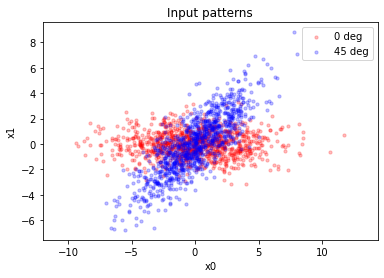

In [ ]:
# Multivariate Gaussian patterns


marker_size = 10
fig, ax = plt.subplots()
ax.scatter(x_init[:, 0], x_init[:, 1], s=marker_size, color="red", alpha=0.25, label="0 deg")
ax.scatter(x[:, 0], x[:, 1], s=marker_size, color="blue", alpha=0.25, label=f"{angle_deg} deg")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Input patterns")
ax.axis("equal")
ax.legend()

## Principal Component Analysis

In this cell, we will perform principal component analysis (PCA) on the rotated dataset and visualize its main ingredients.

We will start by centering the data:
$$
\tilde{x}_\mu = x_\mu - \frac{1}{p}\sum_{\nu=1}^p x_\nu ,
$$
where $x_\mu \in \mathbb{R}^N$ is the $\mu$-th input pattern and $p$ is the number of patterns.

We will then compute the empirical covariance matrix:
$$
C = \frac{1}{p}\tilde{X}^\top \tilde{X},
$$
where $\tilde{X}$ is the matrix of centered data. PCA is obtained by diagonalizing this covariance matrix:
$$
C v_k = \lambda_k v_k .
$$
The eigenvectors $v_k$ are the principal components, and the eigenvalues $\lambda_k$ measure the variance explained along each principal direction.

After computing the eigenvalues and eigenvectors, we will sort the components from largest to smallest eigenvalue, so that $v_1$ is the first principal component. We will also project the data onto these directions:
$$
z_{\mu k} = \tilde{x}_\mu^\top v_k ,
$$
which gives the coordinates, or scores, of each pattern in principal component space.

Finally, we will visualize three things: the principal component directions superimposed on the data cloud, the fraction of variance explained by each component, and the one-dimensional projection of the data onto the first principal component. This PCA solution will provide the benchmark that Oja's rule should recover.

PCs (columns of eigvecs):
[[-0.71634651  0.69774471]
 [-0.69774471 -0.71634651]]
PC eigenvalues:
[9.95479354 1.02953527]
Percent variance explained:
[90.62723553  9.37276447]


Text(0.5, 1.0, 'Dimensionality reduction')

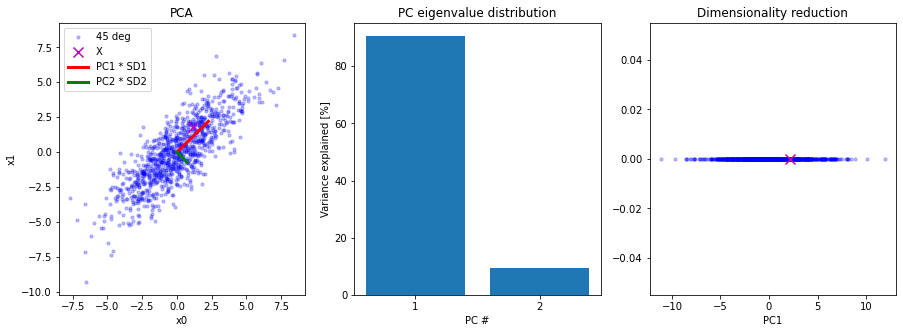

In [ ]:
def empirical_covariance(data: np.ndarray) -> np.ndarray:
    """Return covariance of mean-centered data."""

def pca(data: np.ndarray):
    """Principal component analysis using eigen-decomposition."""



print("PCs (columns of eigvecs):")
print(eigvecs)
print("PC eigenvalues:")
print(eigvals)
print("Percent variance explained:")
print(100 * eigvals / eigvals.sum())


# Optional sign convention for visualization only
if eigvecs[0, 0] < 0 and eigvecs[1, 0] < 0:
    eigvecs[:, 0] *= -1
    scores[:, 0] *= -1
    
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot PCA eigenvectors
ax[0].scatter(x[:, 0], x[:, 1], s=marker_size, color="blue", alpha=0.25, label=f"{angle_deg} deg")
ax[0].scatter(x[-1, 0], x[-1, 1], s=100, color="m", marker="x", label="X")
ax[0].plot([0, np.sqrt(eigvals[0]) * eigvecs[0, 0]],
           [0, np.sqrt(eigvals[0]) * eigvecs[1, 0]],
           color="red", linewidth=3, label="PC1 * SD1")
ax[0].plot([0, np.sqrt(eigvals[1]) * eigvecs[0, 1]],
           [0, np.sqrt(eigvals[1]) * eigvecs[1, 1]],
           color="green", linewidth=3, label="PC2 * SD2")
ax[0].set_xlabel("x0")
ax[0].set_ylabel("x1")
ax[0].set_title("PCA")
ax[0].axis("equal")
ax[0].legend()

# Distribution of eigenvalues
percent_var = 100 * eigvals / eigvals.sum()
pc_index = np.arange(1, len(percent_var) + 1)
ax[1].bar(pc_index, percent_var)
ax[1].set_xlabel("PC #")
ax[1].set_ylabel("Variance explained [%]")
ax[1].set_title("PC eigenvalue distribution")
ax[1].set_xticks(pc_index)

# Dimensionality reduction on PC1
ax[2].scatter(scores[:, 0], np.zeros(n_patterns), s=10, color="blue", alpha=0.25)
ax[2].scatter(scores[-1, 0], 0, s=100, color="m", marker="x", label="X")
ax[2].set_xlabel("PC1")
ax[2].set_title("Dimensionality reduction")


## Activity rule 
Activity: 
$$
{\cal O}=f(h)=\sum_{i=1}^N w_i x_i
$$

## Online training using Oja's learning rule
$$
\Delta w_i=\eta {\cal O}\left(x_i^\mu-\alpha {\cal O} w_i\right)
$$

Initial weights: [6.123234e-17 1.000000e+00]


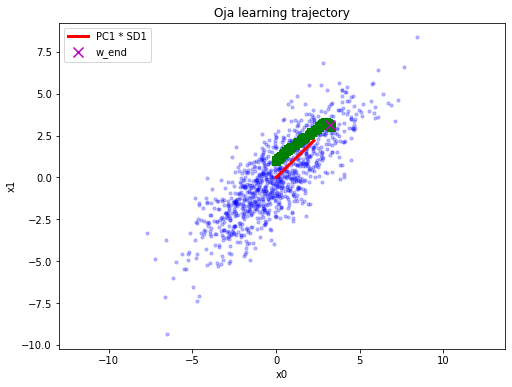

In [ ]:
def oja_update(w: np.ndarray, x_i: np.ndarray, eta: float, alpha: float) -> np.ndarray:



for epoch in range(n_epochs):


w_history = np.array(w_history)
            
# Plot training
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x[:, 0], x[:, 1], s=marker_size, color="blue", alpha=0.25)
ax.plot([0, np.sqrt(eigvals[0]) * eigvecs[0, 0]],
        [0, np.sqrt(eigvals[0]) * eigvecs[1, 0]],
        color="red", linewidth=3, label="PC1 * SD1")
ax.scatter(w_history[:, 0], w_history[:, 1], s=50, marker="s", c="g")
ax.scatter(w_history[-1, 0], w_history[-1, 1], s=100, color="m", marker="x", label="w_end")

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Oja learning trajectory")
ax.axis("equal")
ax.legend()



### Optional assignments: (5+5+5 extra points)

Question 1: Train the network using p=10.000 circular data points generated with covariance matrix C=[[1,0],[0,1]]. Train the network several times starting from different random initial conditions for the weights. What happens to the weights? Train the network for a longer time: what do the weights converge to? Propose an explanation for what you found.



Question 2: Train the network using p=1000 data points generated with covariance matrix C=[[10,0],[0,1]] and mean mu=[10,10]. What happens to the weights? Do the weights still represent the 1st PC, or something else? Why?



Question 3: Train the network using the unsupervised learning rule derived in the previous assignment:
$$
\Delta w_i=\eta[(Cw)_i-\alpha w_i(w^Tw)]
$$
What is the difference between the weights obtained from Oja's rule and the weights obtained from this new rule?